In [16]:
#@title Import Library

import cv2
import numpy as np
import os
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
#@title Upload file datasetnya


from google.colab import files
uploaded = files.upload()

Saving FMD_Cattle.zip to FMD_Cattle.zip


In [18]:
#@title Ambil nama File

filename = list(uploaded.keys())[0]
print("File:", filename)

File: FMD_Cattle.zip


Kode di atas digunakan untuk mengambil nama file yang nantinya digunakan untuk tahap ekstrasi datasetnya


In [19]:
#@title Ekstrak Dataset

extract_path = "/content/datasetuts"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Ekstraksi selesai!")

Ekstraksi selesai!


In [20]:
print(os.listdir(extract_path))

['FMD_Cattle']


In [21]:
#@title Set path
folders = os.listdir(extract_path)

if len(folders) == 1:
    dataset_path = os.path.join(extract_path, folders[0])
else:
    dataset_path = extract_path

print("Dataset path:", dataset_path)

Dataset path: /content/datasetuts/FMD_Cattle


In [40]:
#@title Inisialisasi Data

classes = ["0", "1"]

data = []
labels = []

In [41]:
#@title Preprocessing

def preprocessing(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    img = cv2.resize(img, (128, 128))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    return hsv

In [42]:
#@title Ekstrasi fitur

def extract_features(image):
    hist = cv2.calcHist(
        [image],
        [0,1,2],
        None,
        [32,32,32],
        [0,180,0,256,0,256]
    )

    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [43]:
#@title Load Dataset

for label in classes:
    folder = os.path.join(dataset_path, label)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        img = preprocessing(path)
        if img is None:
            continue

        features = extract_features(img)

        data.append(features)
        labels.append(int(label))

X = np.array(data)
y = np.array(labels)

print("Total data:", len(X))

Total data: 379


In [44]:
#@title Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [45]:
#@title Model Perbandingan

models = {
    "SVM": SVC(kernel='rbf', C=10, gamma=0.01),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

In [46]:
#@title Training dan Evaluasi

results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


===== SVM =====
Accuracy: 0.6052631578947368
Confusion Matrix:
 [[14 27]
 [ 3 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.34      0.48        41
           1       0.54      0.91      0.68        35

    accuracy                           0.61        76
   macro avg       0.68      0.63      0.58        76
weighted avg       0.69      0.61      0.57        76


===== KNN =====
Accuracy: 0.631578947368421
Confusion Matrix:
 [[21 20]
 [ 8 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.51      0.60        41
           1       0.57      0.77      0.66        35

    accuracy                           0.63        76
   macro avg       0.65      0.64      0.63        76
weighted avg       0.66      0.63      0.63        76


===== Random Forest =====
Accuracy: 0.7763157894736842
Confusion Matrix:
 [[26 15]
 [ 2 33]]
Classification Report:
              

In [48]:
print("\n===== HASIL AKHIR =====")
for k, v in results.items():
    print(f"{k}: {v}")

best_model = models["Random Forest"]


===== HASIL AKHIR =====
SVM: 0.6052631578947368
KNN: 0.631578947368421
Random Forest: 0.7763157894736842


In [75]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_pmk_heatmap(model):
    uploaded = files.upload()

    for filename in uploaded.keys():
        print("File:", filename)

        img = cv2.imread(filename)
        if img is None:
            print("Gambar tidak valid")
            return

        original = img.copy()
        h, w, _ = img.shape
        window_size = 64  # ukuran potongan (patch)
        step = 16         # jarak pergeseran

        heatmap = np.zeros((h, w))  # inisialisasi heatmap

        # sliding window (scan gambar)
        for y in range(0, h - window_size, step):
            for x in range(0, w - window_size, step):

                crop = img[y:y+window_size, x:x+window_size]  # ambil patch

                crop_resized = cv2.resize(crop, (128,128))   # resize
                hsv = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2HSV)  # ke HSV

                features = extract_features(hsv).reshape(1, -1)  # ekstraksi fitur

                # ambil probabilitas PMK
                if hasattr(model, "predict_proba"):
                    proba = model.predict_proba(features)
                    confidence = proba[0][1]
                else:
                    confidence = 0.5

                heatmap[y:y+window_size, x:x+window_size] += confidence  # isi heatmap

        heatmap = heatmap / np.max(heatmap)  # normalisasi

        # prediksi global
        img_global = cv2.resize(img, (128,128))
        hsv_global = cv2.cvtColor(img_global, cv2.COLOR_BGR2HSV)

        features_global = extract_features(hsv_global).reshape(1, -1)
        global_pred = model.predict(features_global)[0]

        # confidence global
        if hasattr(model, "predict_proba"):
            conf_global = np.max(model.predict_proba(features_global))
        else:
            conf_global = 0.5

        title = "PMK ⚠️" if global_pred == 1 else "Sehat ✅"

        # tampilkan hasil
        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title(f"Prediksi: {title} (Conf: {conf_global:.2f})")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(heatmap, cmap='jet')
        plt.title("Area Potensi PMK (Heatmap)")
        plt.axis("off")

        plt.show()

Saving Diseased foot 9.jpg to Diseased foot 9.jpg
File: Diseased foot 9.jpg


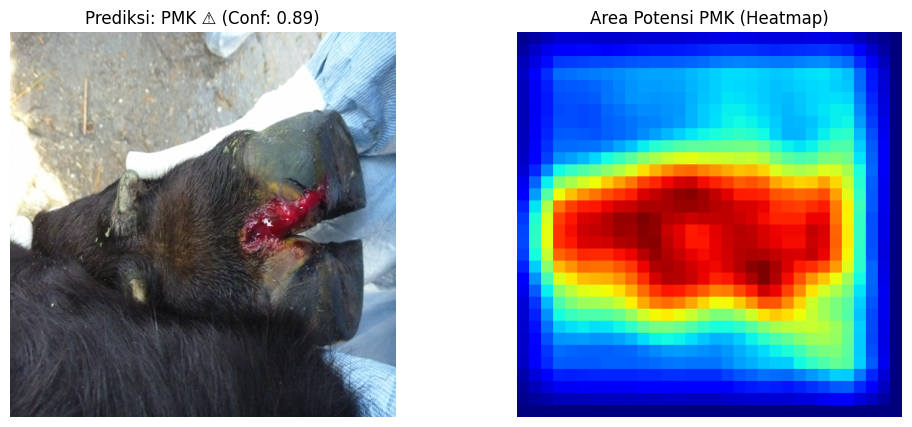

In [74]:
detect_pmk_heatmap(best_model)